In [41]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df_sentiment = pd.read_csv('../data/processed/sentiment_data.csv')
df_topics = pd.read_csv('../data/processed/topic_data.csv')

In [43]:
print(len(df_sentiment))
print(len(df_topics))

8802
8454


In [44]:
df_sentiment

,id,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,bookmarkCount,author,tweet_length,clean_text,sentimen_bert,confidence
0,2058239245148651767,kondisi negara udah bener bener diluar nalar\n...,0,0,0,0,2,2026-05-23,0,ensivo,230,kondisi negara udah benar bener diluar nalar s...,negative,0.989148
1,2058239197652406671,ciecie joong jadi rupiah bgt didepan bininya 🤭...,0,0,0,0,2,2026-05-23,0,natachaintikk,71,ciecie joong jadi rupiah banget didepan bininya,positive,0.534576
2,2058239004710158506,membeli semua make up konser 0 rupiah karena c...,0,0,0,0,0,2026-05-23,0,3JSPACE,63,membeli semua make up konser 0 rupiah karena c...,neutral,0.952872
3,2058238886363668815,Nilai tukar rupiah gak disamain ma yen aja git...,0,1,0,0,2,2026-05-23,0,rainy_snowflake,122,nilai tukar rupiah tidak disamain sama yen saj...,negative,0.777471
4,2058238081271308426,aduh aku bacanya ikutan kaya rupiah,0,0,0,0,3,2026-05-23,0,zss0ur,35,aduh aku bacanya ikutan kaya rupiah,negative,0.989753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,2057009597882544262,Makanya banyak yang bingung kenapa beliau bisa...,0,0,0,0,133,2026-05-20,0,vier4x4,313,makanya banyak yang bingung kenapa beliau bisa...,negative,0.610285
8798,2057009570858557495,Vietnam: Dari Luka Perang Menjadi Macan Ekonom...,0,0,0,0,19,2026-05-20,0,PohanChoky40724,304,vietnam dari luka perang menjadi macan ekonomi...,positive,0.874195
8799,2057008966241247646,Serangan demi serangan datang dari media asing...,0,0,0,0,9,2026-05-20,0,balita655,299,serangan demi serangan datang dari media asing...,positive,0.766140
8800,2057008504138051652,Purbaya beberkan alasan ogah naikkan harga BBM...,0,0,0,0,33,2026-05-20,0,antaranews_bali,125,purbaya beberkan alasan ogah naikkan harga bbm...,neutral,0.998238


In [45]:
df_topics

,id,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,bookmarkCount,author,tweet_length,clean_text,topic
0,2058239245148651767,0,0,0,0,2,2026-05-23,0,ensivo,230,kondisi negara udah benar bener diluar nalar s...,0
1,2058239197652406671,0,0,0,0,2,2026-05-23,0,natachaintikk,71,ciecie joong jadi rupiah banget didepan bininya,3
2,2058239004710158506,0,0,0,0,0,2026-05-23,0,3JSPACE,63,membeli semua make up konser rupiah co pake so...,9
3,2058238886363668815,0,1,0,0,2,2026-05-23,0,rainy_snowflake,122,nilai tukar rupiah disamain sama yen gitu biar...,-1
4,2058238081271308426,0,0,0,0,3,2026-05-23,0,zss0ur,35,aduh aku bacanya ikutan kaya rupiah,3
...,...,...,...,...,...,...,...,...,...,...,...,...
8449,2057009597882544262,0,0,0,0,133,2026-05-20,0,vier4x4,313,makanya banyak bingung beliau bilang masyaraka...,0
8450,2057009570858557495,0,0,0,0,19,2026-05-20,0,PohanChoky40724,304,vietnam luka perang menjadi macan ekonomi asia...,0
8451,2057008966241247646,0,0,0,0,9,2026-05-20,0,balita655,299,serangan serangan datang media asing sebut bor...,0
8452,2057008504138051652,0,0,0,0,33,2026-05-20,0,antaranews_bali,125,purbaya beberkan alasan ogah naikkan harga bbm...,0


In [46]:
sentiment_daily = (df_sentiment.groupby(["createdAt","sentimen_bert"]).size().reset_index(name="count"))
sentiment_daily

,createdAt,sentimen_bert,count
0,2026-04-24,negative,5
1,2026-04-24,neutral,4
2,2026-04-24,positive,6
3,2026-04-25,negative,9
4,2026-04-25,neutral,26
...,...,...,...
84,2026-05-22,neutral,427
85,2026-05-22,positive,169
86,2026-05-23,negative,1115
87,2026-05-23,neutral,770


In [47]:
tweet_volume = (df_sentiment.groupby("createdAt").size().reset_index(name="volume"))
tweet_volume.head()

,createdAt,volume
0,2026-04-24,15
1,2026-04-25,42
2,2026-04-26,51
3,2026-04-27,55
4,2026-04-28,56


In [48]:
negative_count = (df_sentiment[df_sentiment["sentimen_bert"]=="negative"].groupby("createdAt").size())
total_count = (df_sentiment.groupby("createdAt").size())

panic_score=(negative_count/total_count)
panic_score.head()

createdAt
2026-04-24    0.333333
2026-04-25    0.214286
2026-04-26    0.254902
2026-04-27    0.418182
2026-04-28    0.303571
dtype: float64

In [49]:
df_final = pd.merge(
    df_sentiment,
    df_topics[["id","topic"]],
    on="id",
    how="inner"
)
df_final.head()

,id,text,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,bookmarkCount,author,tweet_length,clean_text,sentimen_bert,confidence,topic
0,2058239245148651767,kondisi negara udah bener bener diluar nalar\n...,0,0,0,0,2,2026-05-23,0,ensivo,230,kondisi negara udah benar bener diluar nalar s...,negative,0.989148,0
1,2058239197652406671,ciecie joong jadi rupiah bgt didepan bininya 🤭...,0,0,0,0,2,2026-05-23,0,natachaintikk,71,ciecie joong jadi rupiah banget didepan bininya,positive,0.534576,3
2,2058239004710158506,membeli semua make up konser 0 rupiah karena c...,0,0,0,0,0,2026-05-23,0,3JSPACE,63,membeli semua make up konser 0 rupiah karena c...,neutral,0.952872,9
3,2058238886363668815,Nilai tukar rupiah gak disamain ma yen aja git...,0,1,0,0,2,2026-05-23,0,rainy_snowflake,122,nilai tukar rupiah tidak disamain sama yen saj...,negative,0.777471,-1
4,2058238081271308426,aduh aku bacanya ikutan kaya rupiah,0,0,0,0,3,2026-05-23,0,zss0ur,35,aduh aku bacanya ikutan kaya rupiah,negative,0.989753,3


## Topic Weighting

In [50]:
topic_mapping={
"Global Economic Crisis":[8,6],
"Macroeconomic Crisis & Government Response":[13,12,4,0,10,21],
"Rupiah Exchange Dynamics":[18,20,5,3,15],
"Food Price & Inflation Control":[11,24,19],
"Inflation & Public Economic Impact":[22,9,26,7,2,1,17,14,16],
"Financial Market & Digital Assets":[25,23]
}

In [51]:
topic_to_macro={}

for macro,topics in topic_mapping.items():
    for t in topics:
        topic_to_macro[t]=macro

df_final["macro_topic"]=(df_final["topic"].map(topic_to_macro))
df_final["macro_topic"]=(df_final["macro_topic"].fillna("Outlier"))
df_final[["topic","macro_topic"]].head()

,topic,macro_topic
0,0,Macroeconomic Crisis & Government Response
1,3,Rupiah Exchange Dynamics
2,9,Inflation & Public Economic Impact
3,-1,Outlier
4,3,Rupiah Exchange Dynamics


In [52]:
weights={
"Macroeconomic Crisis & Government Response":1.5,
"Inflation & Public Economic Impact":1.4,
"Rupiah Exchange Dynamics":1.3,
"Food Price & Inflation Control":1.2,
"Global Economic Crisis":1.1,
"Financial Market & Digital Assets":1.0,
"Outlier":0.7
}

df_final["topic_weight"]=(df_final["macro_topic"].map(weights))

In [53]:
sentiment_score={
"negative":1,
"neutral":0.5,
"positive":0.2
}

df_final["sentiment_score"]=(df_final["sentimen_bert"].map(sentiment_score))

## Crisis Score

In [54]:
df_final["crisis_score"]=(df_final["sentiment_score"]*df_final["topic_weight"]*df_final["confidence"])

In [55]:
df_final[["id","sentimen_bert","confidence","macro_topic","topic_weight","crisis_score"]].head()

,id,sentimen_bert,confidence,macro_topic,topic_weight,crisis_score
0,2058239245148651767,negative,0.989148,Macroeconomic Crisis & Government Response,1.5,1.483722
1,2058239197652406671,positive,0.534576,Rupiah Exchange Dynamics,1.3,0.138990
2,2058239004710158506,neutral,0.952872,Inflation & Public Economic Impact,1.4,0.667010
3,2058238886363668815,negative,0.777471,Outlier,0.7,0.544230
4,2058238081271308426,negative,0.989753,Rupiah Exchange Dynamics,1.3,1.286679


In [56]:
df_final["createdAt"]=pd.to_datetime(df_final["createdAt"])

In [57]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8477 entries, 0 to 8476
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               8477 non-null   int64         
 1   text             8477 non-null   str           
 2   retweetCount     8477 non-null   int64         
 3   replyCount       8477 non-null   int64         
 4   likeCount        8477 non-null   int64         
 5   quoteCount       8477 non-null   int64         
 6   viewCount        8477 non-null   int64         
 7   createdAt        8477 non-null   datetime64[us]
 8   bookmarkCount    8477 non-null   int64         
 9   author           8477 non-null   str           
 10  tweet_length     8477 non-null   int64         
 11  clean_text       8477 non-null   str           
 12  sentimen_bert    8477 non-null   str           
 13  confidence       8477 non-null   float64       
 14  topic            8477 non-null   int64         
 15

In [58]:
daily_crisis=(df_final.groupby(df_final["createdAt"].dt.date)["crisis_score"].mean().reset_index())
daily_crisis.columns=["date","avg_crisis_score"]

daily_crisis.head()

,date,avg_crisis_score
0,2026-04-24,0.468680
1,2026-04-25,0.639382
2,2026-04-26,0.657318
3,2026-04-27,0.772307
4,2026-04-28,0.684005


In [59]:
def crisis_level(score):
    if score<0.5:
        return "Low"
    elif score<1:
        return "Medium"
    else:
        return "High"


daily_crisis["crisis_level"]=(daily_crisis["avg_crisis_score"].apply(crisis_level))

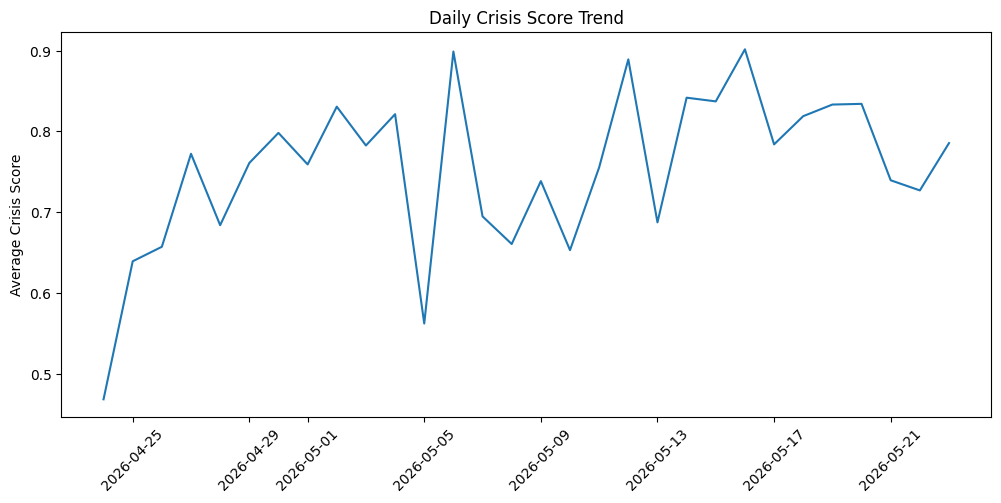

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_crisis["date"],
    daily_crisis["avg_crisis_score"]
)

plt.xticks(rotation=45)
plt.title("Daily Crisis Score Trend")
plt.ylabel("Average Crisis Score")
plt.show()

In [61]:
top_trigger=(
    df_final.groupby("macro_topic")[
        "crisis_score"
        ].mean().sort_values(ascending=False)
    )

print(top_trigger)

macro_topic
Inflation & Public Economic Impact            0.912656
Rupiah Exchange Dynamics                      0.859739
Macroeconomic Crisis & Government Response    0.822836
Financial Market & Digital Assets             0.644011
Food Price & Inflation Control                0.578532
Global Economic Crisis                        0.494584
Outlier                                       0.464495
Name: crisis_score, dtype: float64


In [62]:
df_final.to_csv("../data/processed/final_data.csv", index=False)

In [63]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 8477 entries, 0 to 8476
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               8477 non-null   int64         
 1   text             8477 non-null   str           
 2   retweetCount     8477 non-null   int64         
 3   replyCount       8477 non-null   int64         
 4   likeCount        8477 non-null   int64         
 5   quoteCount       8477 non-null   int64         
 6   viewCount        8477 non-null   int64         
 7   createdAt        8477 non-null   datetime64[us]
 8   bookmarkCount    8477 non-null   int64         
 9   author           8477 non-null   str           
 10  tweet_length     8477 non-null   int64         
 11  clean_text       8477 non-null   str           
 12  sentimen_bert    8477 non-null   str           
 13  confidence       8477 non-null   float64       
 14  topic            8477 non-null   int64         
 15